# Feature Engineering and Modeling

It is the second step after EDA `eda.ipynb`. In this step, we will create new features based on our EDA insights and prepare the data for modeling. Finally, we train the model using Logistic Regression, Random Forest and XGBoost and evaluate its performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
titanic_df = pd.read_csv("../data/train.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    titanic_df.drop(columns=["Survived"]),
    titanic_df["Survived"],
    test_size=0.2,
    random_state=42,
    stratify=titanic_df["Survived"],
)

# Calulate VIF 
Before feature engineering to see the impact of our new features on colinearity

Factor (VIF)**.
- VIF > 10 → strong multicollinearity, consider dropping
- VIF 5–10 → moderate, worth investigating
- VIF < 5 → acceptable

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use numeric columns only; drop rows with NaN so VIF can be computed
numeric_cols = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
vif_df = X_train[numeric_cols].dropna()

vif = pd.DataFrame({
    "Feature": numeric_cols,
    "VIF": [variance_inflation_factor(vif_df.values, i) for i in range(len(numeric_cols))],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif


,Feature,VIF
0,Age,3.559350
1,Pclass,3.468593
2,Fare,1.638055
3,SibSp,1.577103
4,Parch,1.496942


In [9]:
TITLE_MAP = {
    "Mr": "Mr",
    "Miss": "Miss",
    "Mrs": "Mrs",
    "Master": "Master",
    "Dr": "Rare",
    "Rev": "Rare",
    "Col": "Rare",
    "Major": "Rare",
    "Mlle": "Miss",
    "Countess": "Rare",
    "Ms": "Miss",
    "Lady": "Rare",
    "Jonkheer": "Rare",
    "Don": "Rare",
    "Dona": "Rare",
    "Mme": "Mrs",
    "Capt": "Rare",
    "Sir": "Rare",
}


class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Stateless transformer: creates derived features and drops raw columns."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        # Family size (replaces SibSp + Parch)
        df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

        # Cabin presence (binary)
        df["HasCabin"] = df["Cabin"].notna().astype(int)

        # convert sex to binary
        df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

        # Drop columns no longer needed
        df = df.drop(
            columns=["PassengerId", "Ticket", "Cabin", "SibSp", "Parch"]
        )

        return df


class TitleExtractor(BaseEstimator, TransformerMixin):
    """Stateless transformer: extracts a grouped title label from the Name column."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        titles = (
            X["Name"]
            .str.extract(r" ([A-Za-z]+)\.", expand=False)
            .map(TITLE_MAP)
            .fillna("Rare")
        )
        return titles.values.reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return np.array(["Title"])


class GroupMedianImputer(BaseEstimator, TransformerMixin):
    """Imputes a target column using median of specified groups (learned at fit time)."""

    def __init__(self, group_cols=None, target_col="Age"):
        self.group_cols = group_cols or ["Pclass", "Sex"]
        self.target_col = target_col

    def fit(self, X, y=None):
        self.group_medians_ = X.groupby(self.group_cols)[self.target_col].median()
        self.global_median_ = X[self.target_col].median()
        return self

    def transform(self, X):
        df = X.copy()
        mask = df[self.target_col].isna()
        group_keys = df.loc[mask, self.group_cols].apply(tuple, axis=1)
        df.loc[mask, self.target_col] = group_keys.map(self.group_medians_).fillna(
            self.global_median_
        )
        # Return only the target column — group cols were only needed for imputation
        return df[[self.target_col]].values

    def get_feature_names_out(self, input_features=None):
        return np.array([self.target_col])


In [10]:
fare_pipe = Pipeline(
    [
        ("imputer", GroupMedianImputer(group_cols=["Pclass"], target_col="Fare")),
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler()),
    ]
)

# Pclass + Sex passed alongside Age so GroupMedianImputer can compute group medians;
# it outputs only the imputed Age column, which is then scaled.
age_pipe = Pipeline(
    [
        ("imputer", GroupMedianImputer(group_cols=["Pclass", "Sex"], target_col="Age")),
        ("scaler", StandardScaler()),
    ]
)

family_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
    ]
)

embarked_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", sparse_output=False)),
    ]
)

title_pipe = Pipeline(
    [
        ("extractor", TitleExtractor()),
        ("encoder", OneHotEncoder(drop="first", sparse_output=False)),
    ]
)


In [18]:
preprocessor = ColumnTransformer(
    [
        ("fare", fare_pipe, ["Fare", "Pclass"]),
        (
            "age",
            age_pipe,
            ["Age", "Pclass", "Sex"],  # Pclass+Sex needed for group median imputation only
        ),
        ("family", family_pipe, ["FamilySize"]),
        ("embarked", embarked_pipe, ["Embarked"]),
        # ("title", title_pipe, ["Name"]),
        ("passthrough", "passthrough", ["HasCabin", "Pclass", "Sex"]),
    ],
    remainder="drop",
)


In [19]:
# Full preprocessing pipeline: FeatureEngineer → ColumnTransformer
full_pipe = Pipeline([
    ("engineer", FeatureEngineer()),
    ("preprocessor", preprocessor),
])

X_transformed = full_pipe.fit_transform(X_train)
feature_names = full_pipe.named_steps["preprocessor"].get_feature_names_out()

vif_after = pd.DataFrame({
    "Feature": feature_names,
    "VIF": [variance_inflation_factor(X_transformed, i) for i in range(X_transformed.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_after


,Feature,VIF
0,passthrough__Pclass,5.581318
1,embarked__Embarked_S,4.655366
2,fare__Fare,2.024035
3,passthrough__HasCabin,1.833573
4,passthrough__Sex,1.730888
5,embarked__Embarked_Q,1.553835
6,family__FamilySize,1.386535
7,age__Age,1.216667


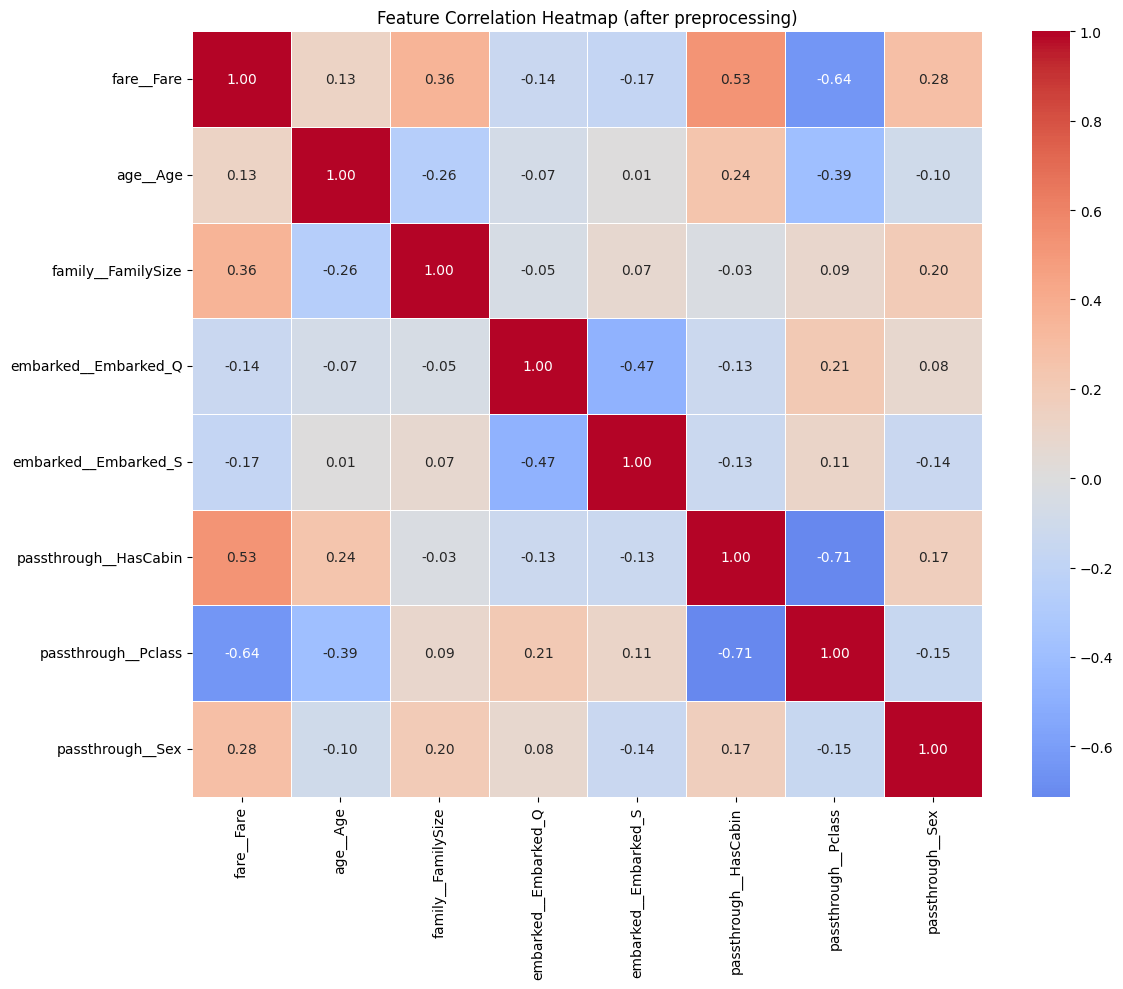

,Feature A,Feature B,Correlation
0,passthrough__HasCabin,passthrough__Pclass,0.712738
1,fare__Fare,passthrough__Pclass,0.640571
2,fare__Fare,passthrough__HasCabin,0.528679
3,embarked__Embarked_Q,embarked__Embarked_S,0.472784
4,age__Age,passthrough__Pclass,0.392024


In [20]:
corr_df = pd.DataFrame(X_transformed, columns=feature_names)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, ax=ax,
)
ax.set_title("Feature Correlation Heatmap (after preprocessing)")
plt.tight_layout()
plt.show()

# Top 5 highly correlated pairs (excluding self-correlation)
corr_pairs = (
    corr_matrix
    .abs()
    .unstack()
    .reset_index()
    .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: "Correlation"})
)
corr_pairs = corr_pairs[corr_pairs["Feature A"] < corr_pairs["Feature B"]]  # remove duplicates
corr_pairs.nlargest(5, "Correlation").reset_index(drop=True)


Title seems to be causing multicollinearity. The title extraction is more towards gender and less towards social status and hence it is highly correlated with Sex. We need to improve the extraction to capture social status otherwise better to drop it.